In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
market_cap = pd.read_excel(
    "../data/raw/supporting/market_cap.xlsx"
)

peer_groups = pd.read_excel(
    "../data/raw/supporting/peer_groups.xlsx"
)

sectors = pd.read_excel(
    "../data/raw/supporting/sectors.xlsx"
)

print("Datasets Loaded")

Datasets Loaded


In [3]:
market_cap.head()

,id,company_id,year,market_cap_crore,enterprise_value_crore,pe_ratio,pb_ratio,ev_ebitda,dividend_yield_pct
0,1,ABB,2019,844312.98,814410.48,19.29,14.26,22.84,0.84
1,2,ABB,2020,923674.33,1120679.72,67.54,13.03,24.93,3.90
2,3,ABB,2021,1020674.09,1166450.81,62.63,6.67,7.58,1.58
3,4,ABB,2022,1185994.82,1158637.42,18.68,4.75,6.12,3.35
4,5,ABB,2023,1161513.28,1103083.77,58.34,12.72,5.70,1.05


In [4]:
market_cap.describe()

,id,year,market_cap_crore,enterprise_value_crore,pe_ratio,pb_ratio,ev_ebitda,dividend_yield_pct
count,552.000000,552.000000,5.520000e+02,5.520000e+02,552.00000,552.000000,552.000000,552.000000
mean,276.500000,2021.500000,9.696238e+05,1.068706e+06,44.22942,7.545870,22.570344,2.255272
std,159.492947,1.709374,6.867611e+05,7.592741e+05,21.25102,4.134385,9.884648,1.337574
min,1.000000,2019.000000,3.336023e+04,3.327706e+04,8.14000,0.510000,5.010000,0.010000
25%,138.750000,2020.000000,3.740344e+05,4.346192e+05,26.45500,4.067500,14.002500,1.050000
50%,276.500000,2021.500000,8.701802e+05,9.502250e+05,43.58500,7.495000,23.000000,2.225000
75%,414.250000,2023.000000,1.401942e+06,1.530386e+06,63.29500,10.957500,31.045000,3.402500
max,552.000000,2024.000000,4.173085e+06,3.837414e+06,79.91000,14.980000,39.720000,4.500000


In [5]:
top_market_cap = (
    market_cap
    .sort_values(
        "market_cap_crore",
        ascending=False
    )
)

top_market_cap[
    ["company_id","market_cap_crore"]
].head(10)

,company_id,market_cap_crore
377,M&M,4173085.48
375,M&M,3425061.30
376,M&M,3314570.19
473,SHREECEM,3154358.33
179,DMART,3053088.97
526,TECHM,3048920.30
374,M&M,3046586.67
527,TECHM,3021095.64
178,DMART,2748638.95
177,DMART,2664977.29


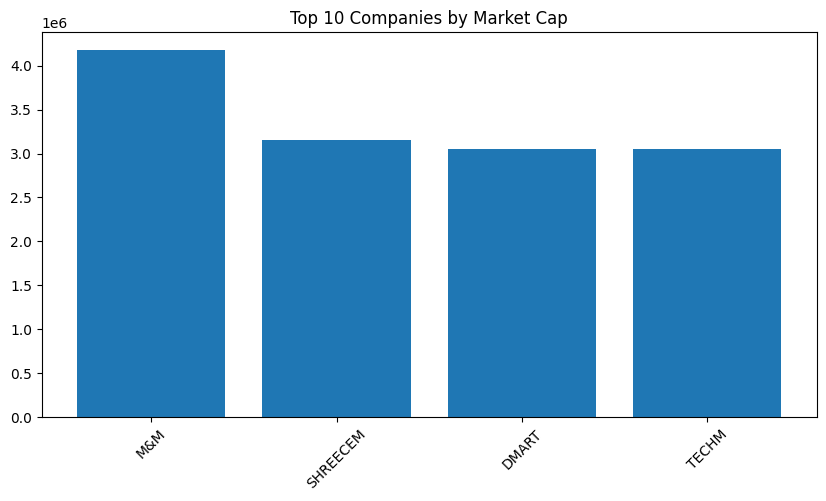

In [6]:
top10 = top_market_cap[
    ["company_id","market_cap_crore"]
].head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["company_id"],
    top10["market_cap_crore"]
)

plt.title("Top 10 Companies by Market Cap")

plt.xticks(rotation=45)

plt.show()

In [7]:
sectors["market_cap_category"].value_counts()

market_cap_category
Large Cap    82
Mid Cap      10
Name: count, dtype: int64

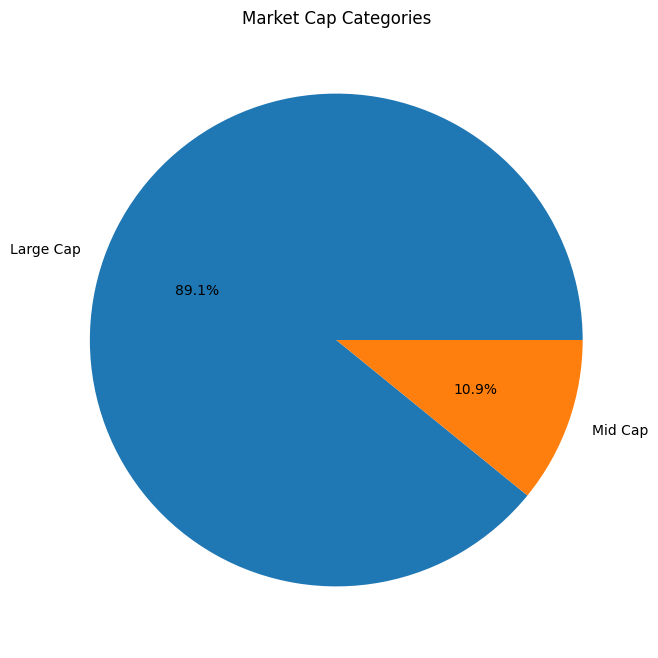

In [8]:
sectors["market_cap_category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(8,8)
)

plt.title("Market Cap Categories")

plt.ylabel("")

plt.show()

In [9]:
benchmark = peer_groups[
    peer_groups["is_benchmark"] == True
]

benchmark

,id,peer_group_name,company_id,is_benchmark
0,1,Private Banks,HDFCBANK,True
5,6,Public Sector Banks,SBIN,True
9,10,IT Services,TCS,True
14,15,Pharmaceuticals,SUNPHARMA,True
19,20,Automobiles,MARUTI,True
26,27,Life Insurance,LICI,True
30,31,Oil & Gas,RELIANCE,True
35,36,Power & Utilities,NTPC,True
42,43,Steel,TATASTEEL,True
46,47,FMCG,HINDUNILVR,True


In [10]:
benchmark["peer_group_name"].value_counts()

peer_group_name
Private Banks          1
Public Sector Banks    1
IT Services            1
Pharmaceuticals        1
Automobiles            1
Life Insurance         1
Oil & Gas              1
Power & Utilities      1
Steel                  1
FMCG                   1
Consumer Finance       1
Name: count, dtype: int64

In [11]:
top10.to_csv(
    "../reports/top_market_cap_day7.csv",
    index=False
)

benchmark.to_csv(
    "../reports/benchmark_companies_day7.csv",
    index=False
)

print("Reports Saved Successfully")

Reports Saved Successfully
